In [211]:
## Graphing for drawing graphs on the evaluated data using evaluate.csv
## Need to query a evaluate.csv file which has around 27,000 records

In [212]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List

In [213]:
from scripts.core.search_evaluation import search_records

In [214]:
CSV_PATH = '/home/suyog/desktop/projects/microlane/results/experiment/evaluate.csv'

df = pd.read_csv(CSV_PATH)

METRICS   = ['accuracy', 'IOU', 'fn', 'fp', 'run_time']
GROUPS    = ['model', 'dataset', 'augmentation']

print(f'Loaded {len(df):,} rows  ×  {df.shape[1]} columns')
df.head(5)

Loaded 27,000 rows  ×  11 columns


,experiment_number,dataset,model,augmentation,raw_file,processed_samples,run_time,accuracy,IOU,fn,fp
0,1,tusimple,ufld,lighting_d,/home/suyog/assets/datasets/TuSimple/TUSimple/...,/home/suyog/assets/datasets/TuSimple/TUSimple/...,0.018957,0.910714,0.989770,0.000000,0.250000
1,2,tusimple,ufld,lighting_d,/home/suyog/assets/datasets/TuSimple/TUSimple/...,/home/suyog/assets/datasets/TuSimple/TUSimple/...,0.004947,0.843750,0.943784,0.000000,0.250000
2,3,tusimple,ufld,lighting_d,/home/suyog/assets/datasets/TuSimple/TUSimple/...,/home/suyog/assets/datasets/TuSimple/TUSimple/...,0.004942,0.575893,0.957459,0.000000,0.500000
3,4,tusimple,ufld,lighting_d,/home/suyog/assets/datasets/TuSimple/TUSimple/...,/home/suyog/assets/datasets/TuSimple/TUSimple/...,0.006487,0.892857,0.954242,0.333333,0.333333
4,5,tusimple,ufld,lighting_d,/home/suyog/assets/datasets/TuSimple/TUSimple/...,/home/suyog/assets/datasets/TuSimple/TUSimple/...,0.005183,0.922619,0.970907,0.000000,0.000000


In [215]:
# DATASETS = ["tusimple", "modified_microlane", "microlane"]
# MODELS = ["ufld", "lanenet", "rld_a", "rld_b "]
# AUGMENTATIONS = ["normal", "motion_blur", "camera_shake", "lighting_b", "lighting_d"]

In [216]:
DATASETS = ["tusimple"]
MODELS = ["lanenet"]
AUGMENTATIONS = ["normal", "motion_blur", "camera_shake", "lighting_b", "lighting_d"]

In [217]:
total_records = []

for dataset in DATASETS:
    for model in MODELS:
        for augmentation in AUGMENTATIONS:
            total_records.append(search_records(df, dataset=dataset, model=model, augmentation=augmentation))

In [218]:
# Cumulative Accuracy
# Line Graph with sample number in x axis

In [219]:
import matplotlib.cm as cm
import numpy as np

def cumulative_accuracy(records: List[List[dict]], metric: str = "accuracy"):
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Generate unique colors for each record
    colors = cm.tab20.colors + cm.tab20b.colors + cm.tab20c.colors  # 60 unique colors
    
    for idx, record in enumerate(records):
        
        if not record:
            continue
        
        cumulative = 0
        n = 0
        cum_avg = []
        
        dataset      = record[0]["dataset"]
        model        = record[0]["model"]
        augmentation = record[0]["augmentation"]
        label = f"{dataset}-{model}-{augmentation}"
        
        for example in record:
            
            accuracy = example[metric]
            
            n += 1
            cumulative = (cumulative * (n - 1) + accuracy) / n
            cum_avg.append(cumulative)
        
        ax.plot(range(1, n + 1), cum_avg, label=label, linewidth=1.5, color=colors[idx % len(colors)])
    
    ax.set_title(f"Cumulative Average {metric.capitalize()}")
    ax.set_xlabel("Samples Added")
    ax.set_ylabel(f"Cumulative Avg {metric.capitalize()}")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()

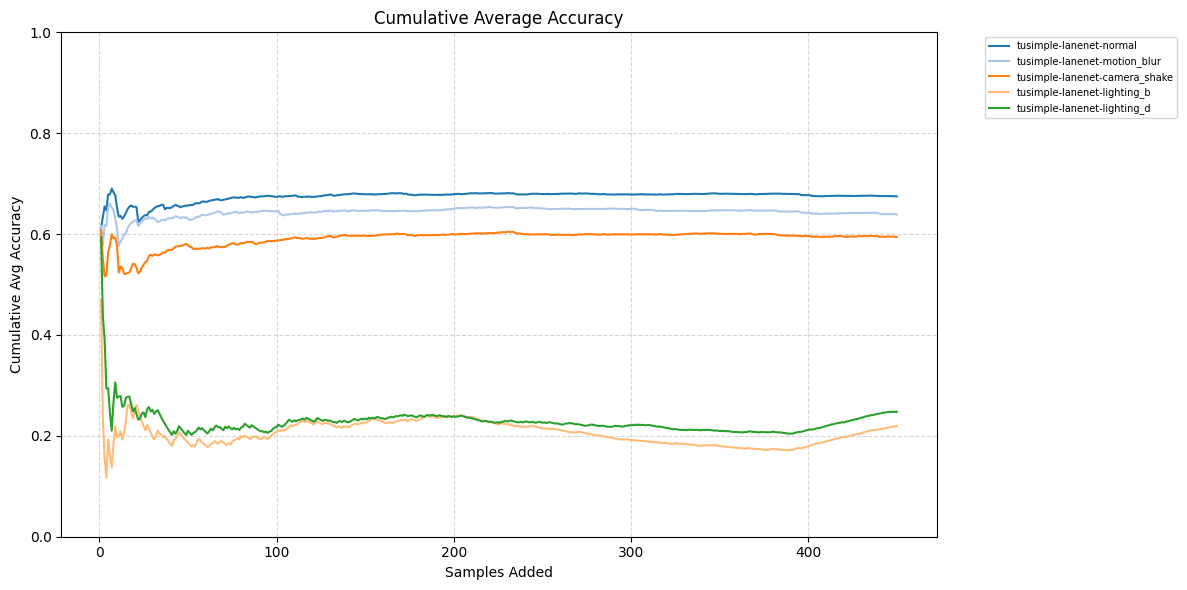

In [220]:
cumulative_accuracy(total_records, metric="accuracy")